## Работа с целевой переменной

#### Цель работы

Познакомиться с основными приемами обработки данных в отношении к целевой переменной: дискретизация, отбор признаков, устранение дисбаланса классов.


#### Методические указания

В предыдущих работах мы занимались предобработкой разных типов данных, ориентируясь на сами характеристики этих данных: их распределения, аномалии, шкалы и так далее. То есть, мы ориентировались на информацию, которую содержат эти переменные изолированно. Однако, для целей моделирования нас в первую очередь интересует то, как тот или иной признак влияет на значение целевой переменной.

В данной работе мы познакомимся с основными операциями обработки данных, которые принимают во внимание соотношение признаков и целевой переменной. Среди них преобразования самой целевой переменной, отбор признаков, работа с несбалансированными датасетами.

##### Отбор признаков по важности

В этой работе мы будем практиковаться на наборах данных с сайте OpenML. Это один их крупных открытых репозиториев датасетов, моделей и алгоритмов машинного обучения, наподобие Kaggle, отличающийся удобным поиском с возможностью фильтрации по датасетам. Что еще более удобно, интеграция с этим репозиторием встроена в библиотеку sklearn, так что можно воспользоваться одной функцией для загрузки датасета. Ее можно импортировать из пакета datasets:


In [1]:
from sklearn.datasets import fetch_openml

Для загрузки датасета нам понадобится указать его имя. Если вы ищете датасет на сайте, то его имя указано в заголовке страницы датасета. Для первого примера мы возьмем датасет mtp, содержащий фармокологические данные. Этот датасет подходит для наших целей: в нем довольно много признаков, не все и которых очень показательны для значения целевой переменной. Кроме названия следует указать версию датасета:

In [2]:
df = fetch_openml("mtp", version=1)

df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


Теперь мы можем оперировать этим датасетом как и любым другим. У датасетов OpenML общий интерфейс: они представляют собой словарь со стандартными ключами. В частности, признаки хранятся по ключу data, а значения целевой переменной - по ключу target. Таким образом, наш датасет уже не нужно разделять на X и y.

Давайте построим распределение целевой переменной:

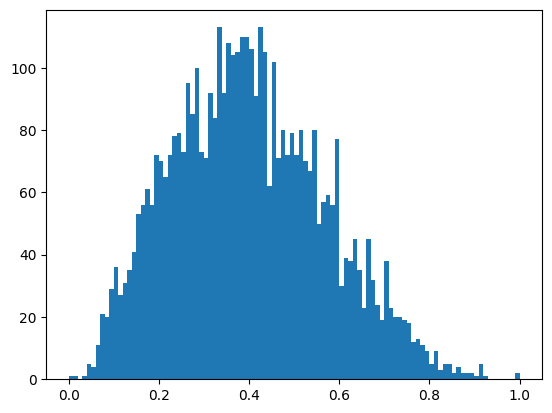

In [5]:
import matplotlib.pyplot as plt


plt.hist(df.target, 100)
_ = plt.plot()

Мы видим, что целевая переменная представляет собой численное значение, что определяет задачу моделирования как регрессию. Кроме того, график показывает, что распределение имеет форму, сходную с нормальным:

о довольно типичное распределение непрерывной величины в естественных данных. Ничего особенно примечательного здесь нет. Мы его построили справочно, более подробно с распредлением целевой переменной будем работать в следующих пунктах.

##### Построение базовой (baseline) модели

Для того, чтобы оценивать эффективность тех или иных методов обработки данных, желательно понимать, как они влияют на эффективность обучаемых моделей. Для этого до начала любых преобразований данных нужно построить базовую простую модель и оценить ее эффективность. Такая базовая модель часто называется простой baseline или базовой моделью. Такая модель позволяет выбрать те способы изменения исходного датасета, которые увеличивают его предсказательную силу, то есть работают на увеличение точности моделей. Именно с бейзлайном мы будем сравнивать эффективность моделей после преобразования данных.

В любом случае, нам потребуется разделить выборку на обучающую и тестовую для несмещенного оценивания уровня эффективности модели. Для еще более точной оценки, можно использовать перекрестную проверку, можете сделать это самостоятельно, мы же воспользуемся обычным разбиением:


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

В качестве базовой модели лучше выбрать простую (вычислительно) модель, которая, желательно, обладает высокой интерпретируемостью. Для этого лучше всего подходят линейные модели и деревья решений. В данном случае, воспользуемся моделью линейной регрессии:

In [10]:
from sklearn.linear_model import LinearRegression

baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.6511340763548095

В данном случае, мы оценивает тестовую эффективность базовой модели по метрике R-квадрат и сохраняем ее в переменную для дальнейшего использования:

Базовая модель демонстрирует очень низкий уровень эффективности, хуже случайности, хуже предсказания среднего значения. Если бы мы продиагностировали ее, мы бы поняли, что проблема в очень высокой вариативности модели. Самая простая модель уже "переобучается" на наших данных. Это происходит потому, что в данных очень много признаков, каждый их которых добавляет одну степень свободы модели (добавляет один обучаемый коэффициент), что увеличивает её сложность. При этом далеко не все эти признаки нужны для предсказания значения целевой переменной. Как правило, при большом количестве признаков, большинство не несет полезной информации.

Еще будет полезно изобразить линию регрессии на графике, чтобы визуально убедиться в ее низком качестве:

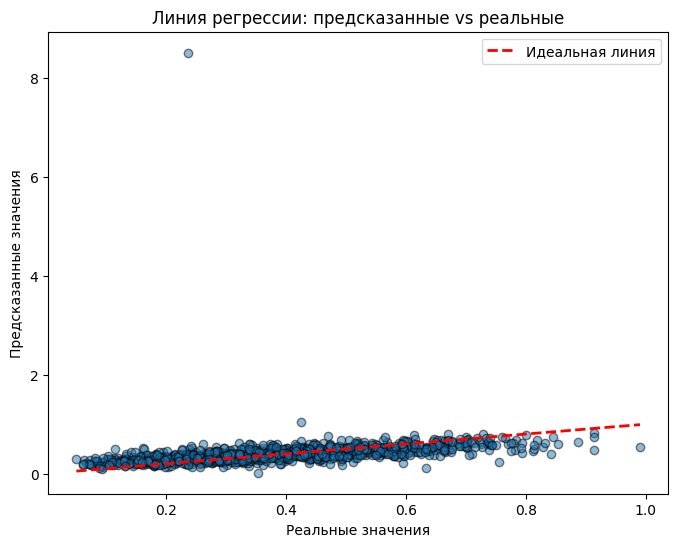

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Предсказания на тестовой выборке
y_pred = baseline.predict(X_test)

# Построение графика (предсказанные vs реальные)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Линия регрессии: предсказанные vs реальные')
plt.legend()
plt.show()

##### Определение относительной важности признаков

Для улучшения работы модели нам нужно избавиться от неинформативных, лишних признаков в датасете. Существует множество стратегий, как можно это сделать. Например, мы можем исключать признаки по одному и следить, исключение каких лучше всего влияет на модель. Однако, эта стратегия, называемая "рекурсивное исключение признаков", будет слишком медленно работать, так как у нас больше 200 признаков и чтобы исключить хотя бы один, нам нужно обучить более 200 моделей и так далее.

Также можно попробовать рекурсивное добавление признаков. В этом случае мы выбираем признак, который дает наибольшую эффективность в задаче парной регрессии. После этого также перебором подбираем к нему второй и так далее. Этот способ будет ненамного быстрее и также потребует большого количества вычислительных ресурсов.

Можно использовать парные статистические критерии, которые оценивают степень взаимного влияния двух переменных. Это, например, хи-квадрат, тест Фишера для задач классификации, коэффициент корреляции для регрессии. В данном случае, можно построить коррелограмму, то есть матрицу коэффициентов парной корреляции. Или просто посчитать корреляцию каждого признака с целевой переменной. После этого останется только выбрать те признаки, у которых такой коэффициент выше.

Как мы говорили в лекциях, коэффициенты обученной модели линейной регрессии имеют очень схожий смысл. Можно посмотреть на коэффициенты обученной модели и выбрать те признаки, коэффициенты при который сильнее отличаются от 0. Однако, этот способ, как и оценка коэффициента корреляции, учитывает только линейную связь между конкретным признаком и целевой переменной.

Можно воспользоваться информацией, которую дает обученная нейлинейная модель. Мы уже говорили, что построение, например, дерева решений позволяет оценить относительную важность признаков. Причем эта важность будет учитывать не только линейное, но и более сложное нелинейное и совместное влияние факторов. Плюс, библиотека sklearn позволяет получить эту информацию автоматически, после обучения модели, нам не нужно специально что-то отдельно вычислять.
Так можно узнать, какие из них оказывают наибольшее влияние на значение целевой переменной.

В данном примере мы используем даже не отдельное дерево, которое может очень сильно переобучиться на нашей выборке, а его более сильную и робастную ансамблевую версию - случайный лес:


In [13]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

По сути, случайный лес - это набор деревьев, каждый из которых видит случайную часть выборки. Более подробно по ансамбли моделей мы поговорим далее в курсе. Сейчас важно, что при помощи свойства feature_importances_ можно получить информацию о важности признаков. Удобнее всего изобразить эту информацию на графике в отсортированном виде:

Text(0.5, 0, 'Feature Importance')

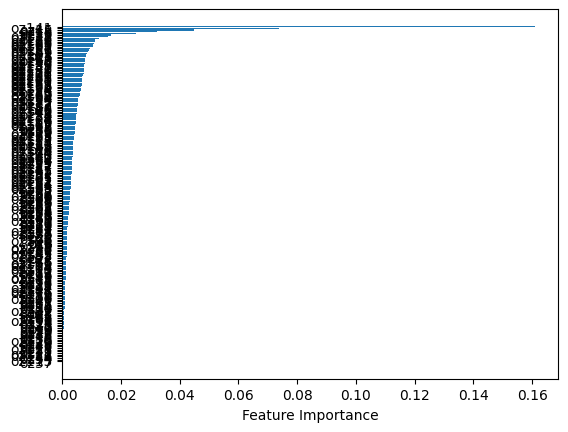

In [14]:
sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel("Feature Importance")

Мы получим столбчатый график, на котором по вертикали отложены все наши признаки, они подписаны слева вдоль вертикальной оси, по горизонтали - отложена относительная важность данного признака. Это условное число, которое показывает, насколько информативен данный признак для предсказания значения целевой переменной:

Из-за того, что у нас более 200 признаков, подпись мало читаются. Можете самостоятельно построить более читаемый график, отобрав, например, только 30 самых значимых признаков. Мы можем просто вывести значимость самых важных колонок датасета:

In [15]:
rf.feature_importances_[sort][-10:]

array([0.01104404, 0.01116662, 0.01246018, 0.01575873, 0.01645314,
       0.02525802, 0.03229703, 0.04491147, 0.0737213 , 0.16086469])

Обратите внимание, из-за того, что для построения графика мы сортировали массив по возрастанию, самые значимые признаки - в конце. Таким образом, нам нужны, например, 10 последних элементов в этом массиве. Вот что получаем:

Более интересна и полезна для нас информация о названиях самых важных признаков. Их тоже можно вывести:

In [16]:
df.data.columns[sort][-10:]

Index(['oz198', 'oz158', 'oz20', 'oz137', 'oz112', 'oz35', 'oz18', 'oz48',
       'oz15', 'oz141'],
      dtype='object')

Мы получаем соответствующее количество признаков, оказывающих наибольшее влияние на целевую переменную. Обратите внимание, что самые важные признаки будут в конце списка. Но для дальнейших целей нам не важен порядок колонок..

Теперь мы можем использовать эту информацию для удаления лишних данных из датасета. Количество самых важных признаков мы выбираем сами. Зачастую для этого используют "метод локтя". Можете самостоятельно попробовать разное количество признаков, мы сейчас возьмем 20:

In [17]:
trimmed = df.data[df.data.columns[sort][-20:]]
trimmed.head()

,oz163,oz117,oz8,oz161,oz162,oz157,oz56,oz197,oz195,oz155,oz198,oz158,oz20,oz137,oz112,oz35,oz18,oz48,oz15,oz141
0,0.059438,0.000000,0.060606,0.382067,0.319206,0.000000,0.126277,0.505899,0.056880,0.752291,0.039213,0.800120,0.000000,0.000000,0.000000,0.0,0.0625,0.312855,0.000000,0.041308
1,0.122765,0.311793,0.373737,0.383458,0.306084,0.000281,0.422015,0.683820,0.287438,0.745984,0.326584,0.791224,0.242424,0.278945,0.222222,0.4,0.0625,0.297041,0.282828,0.212274
2,0.153984,0.000000,0.212121,0.382596,0.406309,0.001852,0.000000,0.499219,0.117431,0.753298,0.204885,0.798276,0.388889,0.000000,0.000000,0.0,0.1250,0.288557,0.388889,0.063643
3,0.110089,0.000000,0.171717,0.382776,0.327848,0.000158,0.000000,0.630533,0.145349,0.767469,0.023469,0.800965,0.095238,0.039437,0.000000,0.1,0.0000,0.310692,0.111111,0.031193
4,0.075031,0.000000,0.101010,0.383539,0.329857,0.000037,0.000000,0.516053,0.067583,0.741548,0.111398,0.802893,0.260870,0.000000,0.000000,0.0,0.0625,0.286581,0.304348,0.063643


Не рекомендуется модифицировать исходную переменную, лучше создать новую копию датасета, в которую перенести только нужные колонки. Конечно, это нужно сделать и в обучающей и в тестовой части выборки. Либо, в исходном общем датасете, а затем повторить разбиение еще раз. Теперь все готово для того, чтобы построить модель на урезанном датасете:

Мы используем тот же класс моделей - линейную регрессию - чтобы различия в метрике были сопоставимы. И мы получаем гораздо более качественную модель. Метрика уже положительна, что свидетельствует о большом росте точности:


In [23]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)


print(bl_score)
print(better.score(X_test, y_test))

-1.6511340763548095
0.38089153322388103


Можно изобразить график модели и визуально, чтобы убедиться в том, что он разительно отличается от графика, который мы получили ранее:



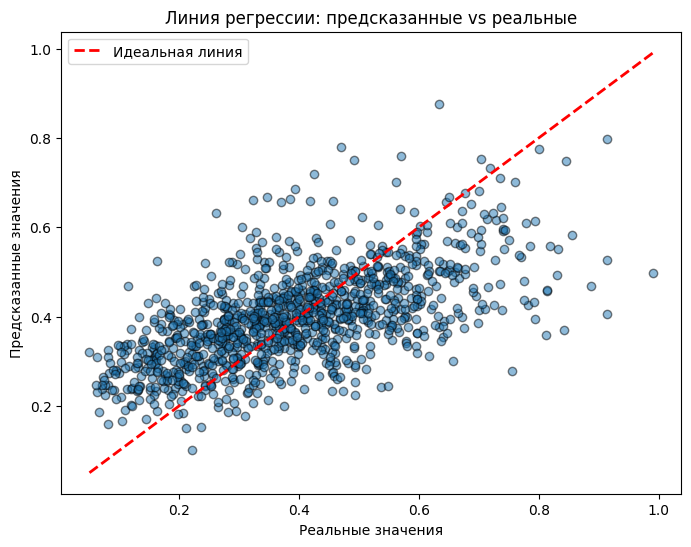

In [24]:


# Предсказания на тестовой выборке
y_pred = better.predict(X_test)

# Построение графика (предсказанные vs реальные)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Линия регрессии: предсказанные vs реальные')
plt.legend()
plt.show()

Регрессия еще далека от идеала, но уже значительно лучше случайности и показывает некоторый уровень эффективности, который может быть приемлемым в зависимости от прикладной задачи.

Мы, конечно, оценивали качество модели только по одной метрике. Можете самостоятельно сравнить значение других метрик качества регрессии на этих двух моделях. Убедитесь, что вторая модель лучше по любой выбранной метрике.

В данном примере сокращение количества столбцов в 10 раз, с 200 до 20, пошло только на пользу модели, так как избавило ее от лишних признаков, которые искусственно завышают сложность и вариативность функции гипотезы за счет введение большого числа коэффициентов. Другими словами, отбор признаков по важности оказывает регуляризирующее действие на модель.

##### Автоматизация отбора признаков

Конечно, отбор признаков - это довольно стандартная процедура при моделировании. В предыдущем примере мы все делали руками. Однако, в библиотеке sklearn есть встроенные средства выбора признаков. Познакомьтесь с ними в документации. Sklearn умеет автоматизировать как рекурсивное исключение и добавление признаков, и отбор по статистическим критериям, так и отбор по результатам обучения модели.

Давайте напомним себе о форме датасета:


In [26]:
df.data.shape

(4450, 202)

Исходно у нас присутствует 202 признака. В sklearn есть специальный объект, SelectFromModel, который находится в пакете feature_selection. Познакомьтесь с документацией к этому классу и к другим классам из данного пакета. Работа с ними напоминает работу с другими классами преобразования данных в том плане, что используется подход fit-transform:

In [27]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
X_trimmed.shape

(4450, 60)

Обратите внимание, что мы передаем в этот объект вид модели машинного обучения, на основе которой будет производиться отбор признаков. При этом, методы fit() объекта SelectFromModel в том числе произведет обучение модели. Помните об этом, если используете ресурсоемкую модель. Данный объект можно настроить для использование уже обученной модели, без повторного запуска обучения.

Также обратите внимание, что мы используем данное преобразование на всем датасете. В дальнейшем мы опять разобьем его на обучающую и тестовую выборки. Однако, так как объект преобразования SelectFromModel сохраняется и "запоминает" нужные признаки, мы можем обучить его и уже после разбиения. В таком случае, метод transform() нужно будет вызвать и для обучающей и для тестовой выборки отдельно. Преобразование будет скоординированным.

Посмотрим, как данный код преобразовал данные:

In [29]:
X_trimmed.shape

(4450, 60)

У нас осталось 55 признаков. Это больше, чем мы использовали в прошлый раз. Решение об этом принимает сам алгоритм SelectFromModel. Его, конечно, тоже можно настроить. Но сейчас давайте проверим, как данная обработка скажется на эффективности модели. Для этого построим уже третью модель на этом датасете:

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340763548095


0.43344310841807643

Сы видим еще большее улучшение по метрикам:

Опять же, самостоятельно оцените данную модель и по другим метрикам регрессии. Особенно интересно ее сравнение со второй моделью. Но по метрика R-квадрат мы видим, что увеличение количества признаков до 55 не привело к переобучению модели. То же можно видеть и по графику.

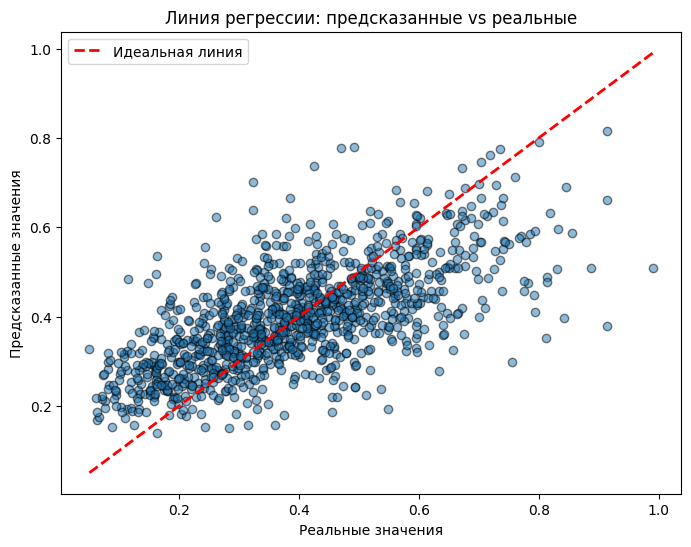

In [31]:


# Предсказания на тестовой выборке
y_pred = better.predict(X_test)

# Построение графика (предсказанные vs реальные)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Линия регрессии: предсказанные vs реальные')
plt.legend()
plt.show()

Найдите самостоятельно, самое оптимальное количество признаков, которые следует оставить в модели для достижения наиболее высокой тестовой эффективности.

##### Устранение дисбаланса классов

Одна из самых частых проблем при построении моделей классификации на реальных данных - дисбаланс классов. Это ситуация, когда в датасете присутствует очень разное количество объектов, принадлежащих разным классам. Другими словами, это неравномерность распределения значений целевой переменной. При этом проблемой такой дисбаланс становится, когда объектов одного класса в несколько раз, а то и десятков раз больше чем другого. На практике, соотношение, например, 100 к 1 не является редкостью.

Это может быть проблемой при обучении моделей потому, что при подборе весов модель будет чаще видеть в обучающих примерах объекты мажоритарного или мажоритарных классов (то есть таких, объектов которых значительно больше). И их влияние на изменение параметров функции гипотезы будет превалировать над влиянием объектов миноритарных классов. В итоге модель может одновременно недообучиться на мажоритарных классах и переобучиться на миноритарных. При анализе результатов моделирования эту проблему проще всего выявить при рассмотрении отчета о классификации - объекты миноритарных классов распознаются значительно хуже.

Давайте обратимся к примеру. Возьмем датасет результатов психологического моделирования:


In [32]:
df = fetch_openml("balance-scale", version=1)

df.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


Этот набор данных не требует технической предварительной обработки для построения модели, поэтому сразу визуализируем распределение целевой переменной:

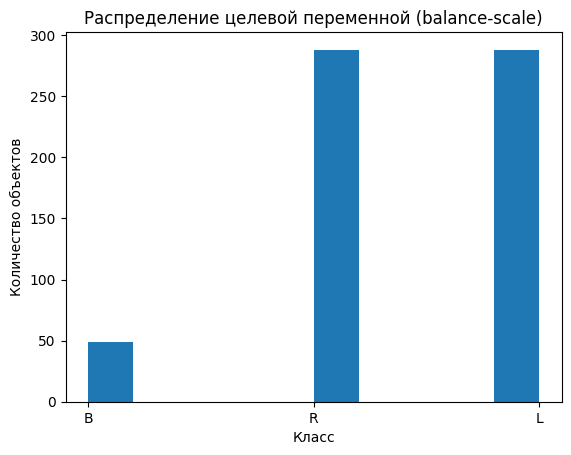

In [38]:
# Визуализация распределения целевой переменной

plt.hist(df.target)
plt.title('Распределение целевой переменной (balance-scale)')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.show()

Мы видим, что объекты объединены в три класса, называемые "B", "R" и "L". Причем, объектов класса "B" примерно в шесть раз меньше, чем каждого из двух других. Это - миноритарный класс, а два других - мажоритарные. Для построения базовой модели, как всегда разделим выборку

In [39]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

Обратите внимание, что при разделении несбалансированных выборок за счет случайных ошибок мы можем существенно сместить форму этого распределения. Вполне вероятно, что объекты миноритарного класса вообще по прихоти случайности не попадут в тестовую выборку, или попадут в еще меньшей доле. Ил наоборот. Этого следует избегать, так как для адекватного оценивания качества модели, обучающая и тестовая выборки должны быть как можно более сходными по своим статистическим характеристикам. Все статистики в выборке мы проконтролировать не можем, но хотя бы должны убедиться, что распределение целевой переменной будет сходным.

Для этого применяют особый прием - стратификацию выборки. В функцию train_test_split можно передать специальный аргумент, который заставит ее учитывать распределение объектов по данной переменной. В нашем случае, мы используем целевую переменную для стратификации. Это гарантирует, что две подвыборки после разделения сохранять форму данного распределения. Убедиться можно на графике построив гистограмму значений целевой переменной в одной из выборок после разделения:

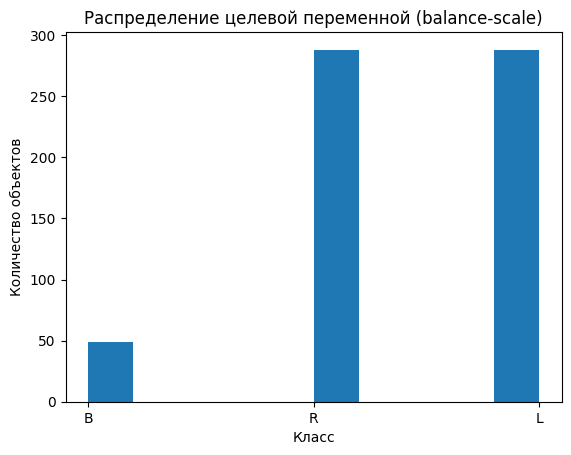

In [59]:
# Визуализация распределения целевой переменной

plt.hist(df.target)
plt.title('Распределение целевой переменной (balance-scale)')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.show()

Теперь мы готовы построить базовую модель. Так как перед нами задача классификации, в качестве базовой выберем логистическую регрессию:

In [43]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

0.8598726114649682

Опять же, можно оценивать модель и по другим метрикам. Более того, постановка задачи будет диктовать нам, какая метрика будет целевой, то есть на какую метрику мы должны ориентироваться в первую очередь при выборе и оценке моделей.

Так как мы исследуем проблему дисбаланса классов, обязательно надо построить отчет о классификации:

In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157



На нем мы видим, что эффективность модели действительно разнится для разных классов:

Еще больше информации дает вывод матрицы классификации:

In [45]:
print(confusion_matrix(y_test, baseline.predict(X_test)))

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


Давайте посмотрим, удастся ли нам улучшить данную модель. Как всегда, есть несколько стратегий борьбы с дисбалансом классов. Здесь рассмотрим два: взвешивание классов и ресемплинг выборки.

Главная проблема дисбаланса классов в том, что модель недостаточно учитывает объекты миноритарных классов. Можно относительно просто это исправить, при обучении модели, придав больший "вес" таким редким объектам. Это называется, взвешивание классов. Для начала надо рассчитать "важность" или вес класса, который будет обратно пропорционален его доле в выборке. Можно сделать это и руками, но в библиотеке sklearn есть встроенная функция для этого:

In [46]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': np.float64(4.216216216216216),
 'L': np.float64(0.7255813953488373),
 'R': np.float64(0.7222222222222222)}

Предпоследняя строчка в этом коде нужна, чтобы правильно отформатировать получившиеся значения в словарь, где ключами являются метки классов, а значениями - вес соответствующего класса:

Мы видим, что вес миноритарного класса действительно вильно больше, чем двух других. Эту информацию можно передать непосредственно модели машинного обучения через параметр конструктора:

In [50]:
weighted = LogisticRegression(class_weight=class_weights)
weighted.fit(X_train, y_train)
print(bl_score)
weighted.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

Такая модель будет сильнее изменять свои веса в ответ на объект миноритарного класса, пропорционально весу этого класса. На самом деле все немного сложнее, так как обучение идет методом пакетного градиентного спуска, в котором на каждом шаге обрабатывается несколько объектов выборки, но смысл именно в этом.

Оценим качество такой модели на отчете о классификации:

In [52]:
print(classification_report(y_test, weighted.predict(X_test)))

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



Мы видим, что точность модели возросла с 86% до 92%. Это очень существенное увеличение эффективности. Причем обратите внимание, что оценивали модель мы на той же тестовой выборке, в которой сохранено исходной неравномерное распределение. То есть это естественное повышение качества. При этом точность модели на этом миноритарном классе все равно немного ниже, чем на других. Это тоже естественно. Но разница уже далеко не такая огромная.

##### Oversampling

Но что делать, если конкретная модель не поддерживает взвешивание классов? Или по какой-то другой причине, такой способ либо не подходит, либо не дает нужного эффекта? Можно использовать ресемплинг - то есть случайную выборку из исходного датасета с выравниванием распределения по классам. Есть две стратегии. Оверсемплинг - это когда мы семплируем в выборку больше объектов мажоритарного класса с повторениями. Андерсемплинг - это исключение случайных объектов мажоритарных классов до выравнивания распределения. Есть гибридный подход - когда мы делаем и то и другое в определенных пропорциях. Кроме того, есть продвинутые техники генерации или аугментации данных для выравнивания распределения.

Покажем на простом примере как работает оверсемплинг. Подсчитаем точное количество объектов каждого класса в обучающей выборке:


In [53]:
y_train.value_counts()

,count
class,
R,216
L,215
B,37


Видим, что объектов миноритарного класса всего 37 против 216 - мажоритарного:

Для дальнейших манипуляций нам будет удобно объединить матрицу признаков и вектор целевой переменной в один датафрейм:

In [54]:
X_train["target"] = y_train

Теперь мы семплируем недостающее количество объектов миноритарного класса из нашего датасета с повторениями:

In [55]:
oversampled = X_train[X_train.target == "B"].sample(n=216-37, replace=True, ignore_index=True)

После этого нам остается только объединить эту новую выборку с исходной:

In [57]:
import pandas as pd

oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
oversampled.head()

(647, 5)


,left-weight,left-distance,right-weight,right-distance,target
262,3,1,3,3,R
401,4,2,1,2,L
174,2,2,5,5,R
81,1,4,2,2,B
36,1,2,3,2,R


Построив распределение целевой переменной мы убеждаемся в том, что оно стало очень близко к равномерному:

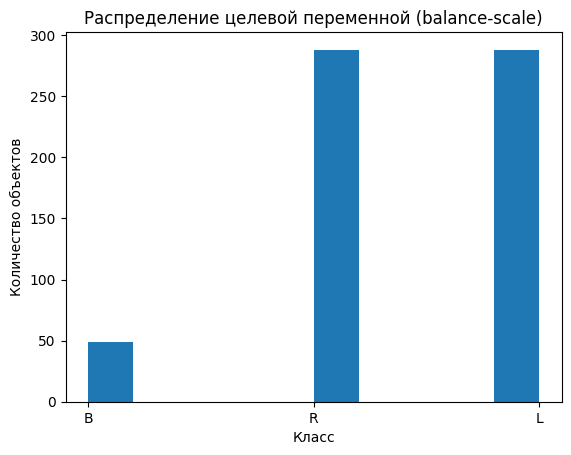

In [60]:
# Визуализация распределения целевой переменной

plt.hist(df.target)
plt.title('Распределение целевой переменной (balance-scale)')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.show()

Другими словами, мы просто добавили в обучающую выборку дубликаты объектов миноритарного класса в нужном объеме. В итоге, по задумке этого метода, при обучении модель будет чаще видеть такие объекты (пусть одни и те же) и будет подстраивать свои веса под них в том же темпе, что и под объекты мажоритарных классов. Проверим это. Опять разделим датафрейм на матрицу признаков и целевой вектор:

In [61]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop(["target"], axis=1)

И построим такую же модель логистической регрессии. Теперь никакое взвешивание классов не понадобится, мы сделали все руками:

In [62]:
OSmodel = LogisticRegression()
OSmodel.fit(X_train_OS, y_train_OS)
print(bl_score)
OSmodel.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

При оценке качества этой модели получаем такую же картину, что и после взвешивания:

In [65]:
# Правильно: используем обученную модель OSmodel
print(classification_report(y_test, OSmodel.predict(X_test)))

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



Данные стратегии производят очень схожий эффект на процесс обучения модели.

##### Дискретизация целевой переменной

Для освоения следующего приема обработки данных воспользуемся другим датасетом, но из того же репозитория. После чтения сразу подготовим его к моделированию:


In [66]:
df = fetch_openml("CPMP-2015-regression", version=1)
df.data.drop(["instance_id"], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)
df.data.head()

/tmp/ipykernel_3978/1011001378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.data.drop(["instance_id"], inplace=True, axis=1)


,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


Это набор данных о бенчмарке решения математической проблемы нахождения оптимальной сортировки на контейнерной площадке. В этом наборе нам более всего важно распределение целевой переменной:


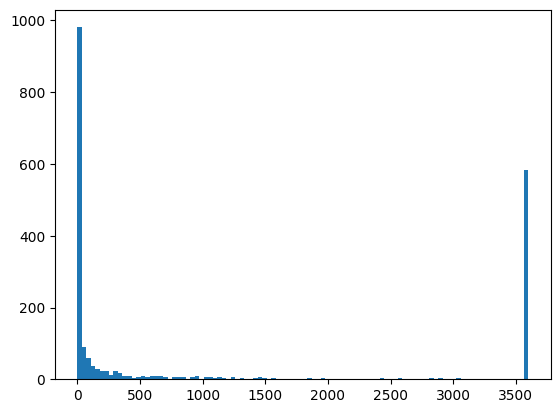

In [67]:
plt.hist(df.target, 100)
_ = plt.plot()

Мы видим, что целевая переменная имеет численный вид (то есть перед нами проблема регрессии), и при этом, распределена очень неравномерно:



Это не красивое около-нормальное распределение из предыдущего примера. Это очень очень несбалансированное двухмодальное распределение. Есть большое количество объектов в датасете, у которых значение целевой переменной близко к 0, чуть меньшее, но тоже большое количество объектов, у которых оно близко к максимальному (порядка 3 500), и очень мало объектов с промежуточными значениями.

Такое странное неравномерное распределение может повлечь проблемы при моделировании. Проблема сходная с дисбалансом классов, но для регрессии. Модель будет при своем обучении очень часто видеть объекты со схожим значениями целевой переменной и очень редко - объекты с промежуточными. В итоге модель может не научится распознавать такие промежуточные объекты.

Покажем, как можно уменьшить влияние такого распределения. Но сначала разделим датасет на обучающую и тестовую выборки, чтобы отдельно обработать их уже после разделения:

In [68]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

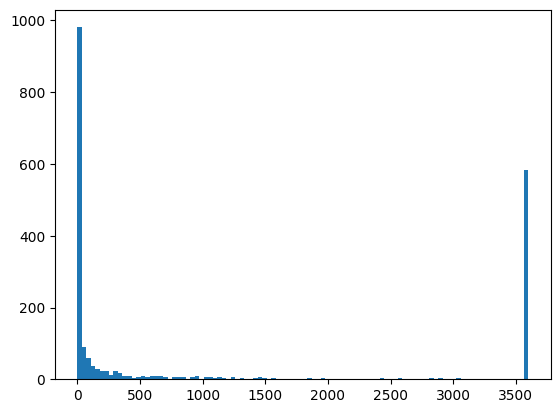

In [70]:
plt.hist(df.target, 100)
_ = plt.plot()

Мы можем исправить неравномерность распределения разными способами, среди которых также ресемплирование выборки, как и в случае с классификацией. Но здесь покажем другой подход - дискретизацию целевой переменной. Этот способ заключается в том, что мы объединяем значения целевой переменной в категории - bins - поэтому такой способ часто называют биннинг.

Группировать объекты можно опять же по-разному. Для автоматизации этой процедуры в библиотеке sklearn есть специальный объект - KBinsDiscretizer, который находится в пакете preprocessing. Воспользуемся им и создадим, например, пять групп:

In [71]:
from sklearn.preprocessing import KBinsDiscretizer

y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform").fit_transform(pd.DataFrame(y_train))

Группировка объектов означает, что мы переходим к категориальному типу в целевой переменной. Каждая категория будет обозначать некоторый диапазон исходных значений. При этом категории нумеруются последовательно, как при применении OrdinalEncoder при кодировании категориальных признаков. Но в этом случае, применение такой кодировки оправдано, так как эти категории, обозначая диапазоны значений численной шкалы, имеют естественный порядок. Вот как выглядят значения целевой переменной после дискретизации:

In [73]:
# Выводим первые 10 значений
print(y_binned[:10])

[[4.]
 [0.]
 [4.]
 [0.]
 [0.]
 [0.]
 [2.]
 [4.]
 [1.]
 [4.]]


Самая простая стратегия биннинга, которая применяется в этом объекте по умолчанию - равномерная. Она делит существующий диапазон значений на указанное количество равных по величине поддиапазонов, каждый из которых кодируется последовательным натуральным числом. По сути, мы просто укрупняем целевую переменную. Если раньше у нас было произвольно большое количество значений, потенциально равное количеству объектов в выборке, то после дискретизации остается указанное количество, в нашем примере - пять. Давайте визуализируем получившееся распределение:



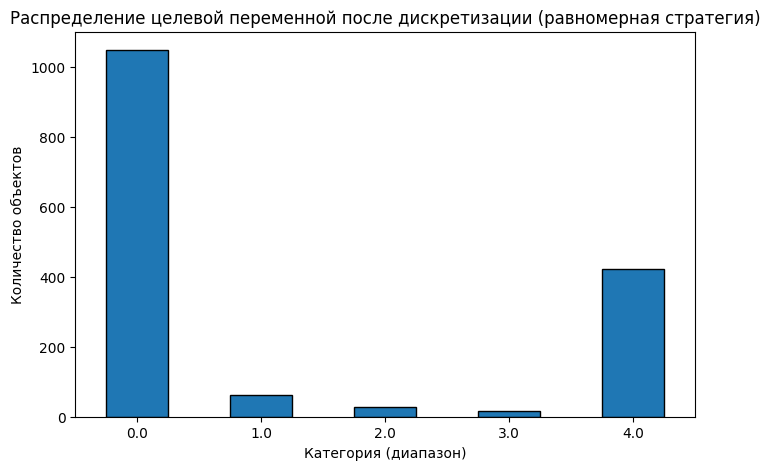

In [76]:
# Преобразуем в одномерный массив и в DataFrame для удобства
y_binned_1d = y_binned.ravel()
y_binned_series = pd.Series(y_binned_1d, name='binned_target')

# Визуализация распределения после дискретизации
plt.figure(figsize=(8, 5))
y_binned_series.value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title('Распределение целевой переменной после дискретизации (равномерная стратегия)')
plt.xlabel('Категория (диапазон)')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.show()

Естественно, так как мы используем равномерные диапазоны, в крайних поддиапазонах соберутся большинство объектов выборки. Мы это видим на графике - столбцы укрупнились, но неравномерность распределения никуда не делась. В случае таких сильно неравномерных распределений нам больше подойдет другая стратегия - квантильная дискретизация, при которой длина диапазонов выбирается таким образом, чтобы в каждом из них оказалось примерно по одинаковому количеству объектов выборки:

In [77]:
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


(array([0, 1, 2, 3]),
 [Text(0, 0, '0.0'), Text(1, 0, '1.0'), Text(2, 0, '2.0'), Text(3, 0, '3.0')])

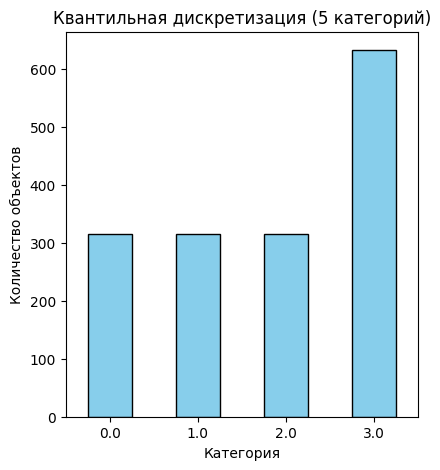

In [78]:
# Квантильная дискретизация (равное количество объектов в каждой категории)
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))
y_binned_1d = y_binned.ravel()
y_binned_series = pd.Series(y_binned_1d, name='binned_target')

# Визуализация
plt.figure(figsize=(10, 5))

# Столбчатая диаграмма
plt.subplot(1, 2, 1)
y_binned_series.value_counts().sort_index().plot(kind='bar', edgecolor='black', color='skyblue')
plt.title('Квантильная дискретизация (5 категорий)')
plt.xlabel('Категория')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)

Обратите внимание, что на диаграмме четыре столбика, причем последний в два раза выше. Это всего лишь артефакт визуализации, в которой две последние категории объединились. Самостоятельно поэкспериментируйте с визуализацией и выберите такой график, который корректно показывает получившееся распределение.

#### Задания для самостоятельного выполнения

1. Исследуйте связь между количеством самых важных признаков, которые использует модель для обучения и тестовой точностью получившейся модели. Обучите несколько моделей с разным количеством наиболее важных признаков. Постройте график зависимости точности модели от количества признаков. Сделайте вывод.


In [81]:
# 1. Загрузка данных
df = fetch_openml("mtp", version=1)

# 2. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

# 3. Оценка важности признаков через Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # сортировка по убыванию

In [83]:
from sklearn.metrics import r2_score

# 4. Эксперимент с разным количеством признаков
n_features_list = [5, 10, 20, 30, 40, 50, 60, 70, 80, 100, 140, 180, 202]
r2_scores = []

for n in n_features_list:
    # Выбираем топ-n признаков
    top_features = df.data.columns[sorted_idx[:n]]
    X_train_trim = X_train[top_features]
    X_test_trim = X_test[top_features]

    # Обучаем линейную регрессию
    lr = LinearRegression()
    lr.fit(X_train_trim, y_train)
    y_pred = lr.predict(X_test_trim)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    print(f"Количество признаков: {n:3d}, R²: {r2:.4f}")

Количество признаков:   5, R²: 0.2861
Количество признаков:  10, R²: 0.3465
Количество признаков:  20, R²: 0.3671
Количество признаков:  30, R²: 0.3756
Количество признаков:  40, R²: 0.4315
Количество признаков:  50, R²: 0.4401
Количество признаков:  60, R²: 0.4398
Количество признаков:  70, R²: 0.4481
Количество признаков:  80, R²: 0.4601
Количество признаков: 100, R²: 0.4403
Количество признаков: 140, R²: 0.4744
Количество признаков: 180, R²: 0.4893
Количество признаков: 202, R²: -1.6511


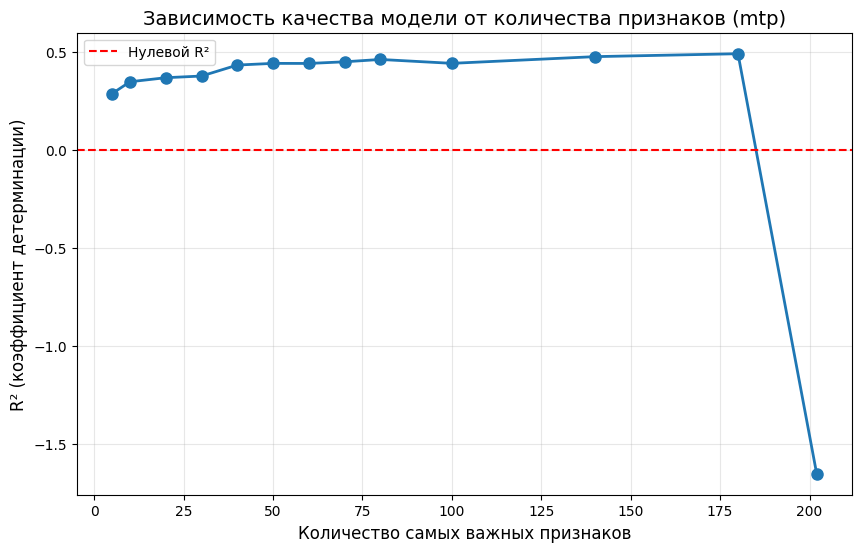

In [84]:
# 5. График зависимости R² от количества признаков
plt.figure(figsize=(10, 6))
plt.plot(n_features_list, r2_scores, 'o-', linewidth=2, markersize=8)
plt.axhline(y=0, color='red', linestyle='--', label='Нулевой R²')
plt.xlabel('Количество самых важных признаков', fontsize=12)
plt.ylabel('R² (коэффициент детерминации)', fontsize=12)
plt.title('Зависимость качества модели от количества признаков (mtp)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [85]:
# 6. Оптимальное количество признаков
best_n = n_features_list[np.argmax(r2_scores)]
print(f"\nОптимальное количество признаков: {best_n}")
print(f"Максимальный R²: {max(r2_scores):.4f}")


Оптимальное количество признаков: 180
Максимальный R²: 0.4893


## Вывод по заданию 1

- **Оптимальное количество признаков:** 180 (R² = 0.489)
- Максимальная точность достигается при использовании **большого количества признаков** (≈140–180).
- При 202 признаках (все признаки) происходит резкое падение качества (R² = -1.65) из-за переобучения.
- **Рост точности:** с 0.286 (5 признаков) до 0.489 (180 признаков) – улучшение на 70%.

**Заключение:** На данном датасете лучше использовать не только топ-признаки, а почти все (кроме явных выбросов). Полный набор признаков (202) переобучается, а оптимальное количество – около 180. Это означает, что "мусорные" признаки действительно вредят модели, но их число невелико (≈20).

2. Используйте другие методы отбора признаков:
   2.1. Исключение низкодисперсных признаков;
   2.2. Исключение по парным статистическим критериям (хи-квадрат, тест Фишера, коэффициент корреляции, информационный критерий);
   2.3. Рекурсивное исключение признаков;
   2.4. Последовательное включение признаков;
   2.5. Исключение по L1-норме (гребневой регрессии).


In [87]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, RFE, SequentialFeatureSelector

# 2.1. Исключение низкодисперсных признаков
selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train)
X_test_var = selector_var.transform(X_test)
lr_var = LinearRegression().fit(X_train_var, y_train)
r2_var = r2_score(y_test, lr_var.predict(X_test_var))
print(f"2.1. VarianceThreshold (дисперсия > 0.01): {X_train_var.shape[1]} признаков, R² = {r2_var:.4f}")

2.1. VarianceThreshold (дисперсия > 0.01): 134 признаков, R² = -1.4759


In [88]:
# 2.2. Исключение по F-статистике (коэффициент корреляции)
selector_f = SelectKBest(f_regression, k=50)
X_train_f = selector_f.fit_transform(X_train, y_train)
X_test_f = selector_f.transform(X_test)
lr_f = LinearRegression().fit(X_train_f, y_train)
r2_f = r2_score(y_test, lr_f.predict(X_test_f))
print(f"2.2. SelectKBest (F-статистика, k=50): R² = {r2_f:.4f}")

2.2. SelectKBest (F-статистика, k=50): R² = 0.4467


In [89]:
# 2.3. Рекурсивное исключение признаков (RFE)
selector_rfe = RFE(LinearRegression(), n_features_to_select=50)
X_train_rfe = selector_rfe.fit_transform(X_train, y_train)
X_test_rfe = selector_rfe.transform(X_test)
lr_rfe = LinearRegression().fit(X_train_rfe, y_train)
r2_rfe = r2_score(y_test, lr_rfe.predict(X_test_rfe))
print(f"2.3. RFE (50 признаков): R² = {r2_rfe:.4f}")


2.3. RFE (50 признаков): R² = 0.3546


In [90]:
# 2.4. Последовательное включение признаков (SequentialFeatureSelection - требует времени!)
# Используем Ridge для устойчивости
selector_seq = SequentialFeatureSelector(Ridge(alpha=1.0), n_features_to_select=50, direction='forward', cv=3)
X_train_seq = selector_seq.fit_transform(X_train, y_train)
X_test_seq = selector_seq.transform(X_test)
lr_seq = LinearRegression().fit(X_train_seq, y_train)
r2_seq = r2_score(y_test, lr_seq.predict(X_test_seq))
print(f"2.4. Sequential Forward Selection (50 признаков): R² = {r2_seq:.4f}")

2.4. Sequential Forward Selection (50 признаков): R² = 0.4782


In [91]:
# 2.5. Исключение по L1-норме (Lasso – отбор признаков за счёт регуляризации)
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)
selected = np.where(lasso.coef_ != 0)[0]
X_train_lasso = X_train.iloc[:, selected]
X_test_lasso = X_test.iloc[:, selected]
lr_lasso = LinearRegression().fit(X_train_lasso, y_train)
r2_lasso = r2_score(y_test, lr_lasso.predict(X_test_lasso))
print(f"2.5. Lasso (α=0.001): {len(selected)} признаков, R² = {r2_lasso:.4f}")


2.5. Lasso (α=0.001): 23 признаков, R² = 0.4015


In [92]:
# 2.6. Результаты сравнения
print("\n=== Сравнение методов отбора признаков ===")
print(f"Baseline (все 202 признака): R² = {r2_score(y_test, LinearRegression().fit(X_train, y_train).predict(X_test)):.4f}")
print(f"VarianceThreshold: {r2_var:.4f}")
print(f"SelectKBest (F-test): {r2_f:.4f}")
print(f"RFE: {r2_rfe:.4f}")
print(f"Sequential Forward: {r2_seq:.4f}")
print(f"Lasso: {r2_lasso:.4f}")


=== Сравнение методов отбора признаков ===
Baseline (все 202 признака): R² = -1.6511
VarianceThreshold: -1.4759
SelectKBest (F-test): 0.4467
RFE: 0.3546
Sequential Forward: 0.4782
Lasso: 0.4015


In [93]:
# Данные
methods = ['Baseline (202)', 'VarianceThreshold', 'SelectKBest (F-test)', 'RFE', 'Forward Selection', 'Lasso']
r2_scores = [-1.6511, -1.4759, 0.4467, 0.3546, 0.4782, 0.4015]
n_features = [202, 134, 50, 50, 50, 23]

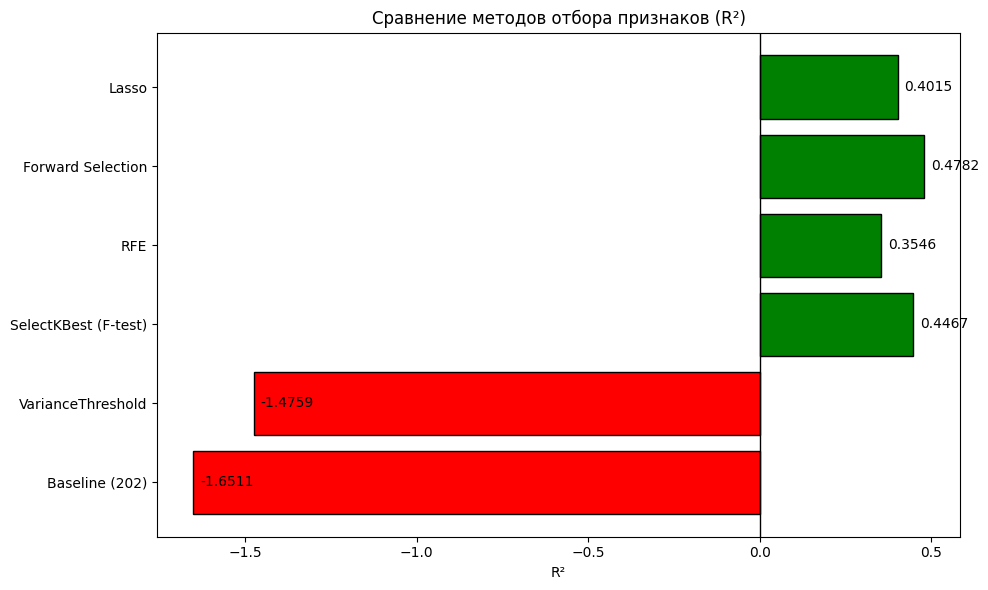

In [95]:
# Цвета: красный для отрицательных, зелёный для положительных
colors = ['red' if x < 0 else 'green' for x in r2_scores]

# 1. Столбчатая диаграмма R²
plt.figure(figsize=(10, 6))
bars = plt.barh(methods, r2_scores, color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('R²')
plt.title('Сравнение методов отбора признаков (R²)')
for bar, val in zip(bars, r2_scores):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()



## Вывод по визуализации

- **Baseline (202 признака)** и **VarianceThreshold** дают отрицательный R² – модель хуже случайного угадывания.
- **SelectKBest (F-test)**: R² = 0.447 при 50 признаках – хороший баланс.
- **RFE**: R² = 0.355 – хуже SelectKBest.
- **Forward Selection**: R² = 0.478 – лучший результат, но требует много времени.
- **Lasso**: R² = 0.402 при всего 23 признаках – хороший компромисс (мало признаков, качество приемлемое).
- **Рекомендация:** использовать **Forward Selection** для максимальной точности или **Lasso** для простоты и интерпретируемости.

3. Изучите возможности библиотеки [imbalanced-learn](https://imbalanced-learn.org/stable/). Примените на данном примере возможности данной библиотеки для оверсемплинга и андерсемплинга выборки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Загружаем датасет
df = fetch_openml("balance-scale", version=1)
X = df.data
y = df.target

# Разделяем на обучающую и тестовую выборки (со стратификацией!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Распределение классов в ИСХОДНОЙ обучающей выборке:")
print(y_train.value_counts())

Распределение классов в ИСХОДНОЙ обучающей выборке:
class
R    216
L    215
B     37
Name: count, dtype: int64


In [3]:
from imblearn.over_sampling import RandomOverSampler

# 1. Применяем oversampling ТОЛЬКО к обучающей выборке
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("\nРаспределение классов ПОСЛЕ RandomOverSampler:")
print(pd.Series(y_train_resampled).value_counts())

# 2. Обучаем модель (логистическую регрессию) на сбалансированных данных
model_ros = LogisticRegression(max_iter=1000)
model_ros.fit(X_train_resampled, y_train_resampled)

# 3. Оцениваем на исходной тестовой выборке
y_pred_ros = model_ros.predict(X_test)
print("\n=== Отчет о классификации после RandomOverSampler ===")
print(classification_report(y_test, y_pred_ros))


Распределение классов ПОСЛЕ RandomOverSampler:
class
B    216
L    216
R    216
Name: count, dtype: int64

=== Отчет о классификации после RandomOverSampler ===
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



In [4]:
from imblearn.under_sampling import RandomUnderSampler

# 1. Применяем undersampling ТОЛЬКО к обучающей выборке
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("\nРаспределение классов ПОСЛЕ RandomUnderSampler:")
print(pd.Series(y_train_under).value_counts())
print(f"Размер новой обучающей выборки: {X_train_under.shape[0]} (было {X_train.shape[0]})")

# 2. Обучаем модель
model_rus = LogisticRegression(max_iter=1000)
model_rus.fit(X_train_under, y_train_under)

# 3. Оцениваем
y_pred_rus = model_rus.predict(X_test)
print("\n=== Отчет о классификации после RandomUnderSampler ===")
print(classification_report(y_test, y_pred_rus))


Распределение классов ПОСЛЕ RandomUnderSampler:
class
B    37
L    37
R    37
Name: count, dtype: int64
Размер новой обучающей выборки: 111 (было 468)

=== Отчет о классификации после RandomUnderSampler ===
              precision    recall  f1-score   support

           B       0.41      0.92      0.56        12
           L       0.98      0.81      0.89        73
           R       0.96      0.93      0.94        72

    accuracy                           0.87       157
   macro avg       0.78      0.89      0.80       157
weighted avg       0.93      0.87      0.89       157



## Вывод по заданию 3 (imbalanced-learn)

- **RandomOverSampler** уравнял классы до 216 объектов: recall класса B = 92%, f1 = 0.73, accuracy = 92%.
- **RandomUnderSampler** сократил выборку до 111 объектов: recall класса B = 92%, f1 = 0.56, accuracy = 87%.
- **Лучший метод:** RandomOverSampler (выше точность и f1-score для миноритарного класса).
- Оба метода решили проблему дисбаланса, подняв recall с 0% до 92%.

4. Исследуйте влияние дискретизации целевой переменной на качество модели. Используйте уже продемонстрированный подход - построение базовой модели (baseline) и сравнение модели после обработки данных с базовой. Проверьте разное количество категорий, а также разные стратегии группировки. Сделайте выводы. Обратите внимание, что после биннинга целевой переменной она стала категориальной. А значит, задача превратилась в задачу классификации.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import r2_score

# 1. Загрузка данных
df = fetch_openml("CPMP-2015-regression", version=1)
X = df.data.drop(['instance_id'], axis=1) if 'instance_id' in df.data.columns else df.data
X = pd.get_dummies(X)
y = df.target

# 2. Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Baseline (линейная регрессия)
lr_baseline = LinearRegression().fit(X_train, y_train)
r2_baseline = r2_score(y_test, lr_baseline.predict(X_test))
print(f"Baseline (LinearRegression, непрерывная цель): R² = {r2_baseline:.4f}")

Baseline (LinearRegression, непрерывная цель): R² = 0.8920


In [19]:
import warnings
warnings.filterwarnings('ignore')

# 4. Эксперимент с дискретизацией
n_bins_list = [3, 5, 10]
strategies = ['uniform', 'quantile']
results = []

for n_bins in n_bins_list:
    for strategy in strategies:
        # Дискретизация целевой переменной
        y_binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy)
        y_train_binned = y_binner.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype(int)

        # Обучение классификатора
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_train, y_train_binned)

        # Предсказание категорий
        y_pred_binned = clf.predict(X_test)

        # Восстановление численных значений по центрам интервалов
        bin_edges = y_binner.bin_edges_[0]
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        y_pred_numeric = bin_centers[y_pred_binned]

        # Метрика
        r2_disc = r2_score(y_test, y_pred_numeric)

        results.append({
            'n_bins': n_bins,
            'strategy': strategy,
            'r2': r2_disc
        })

        print(f"n_bins={n_bins}, strategy={strategy}: R² = {r2_disc:.4f}")

n_bins=3, strategy=uniform: R² = 0.8092
n_bins=3, strategy=quantile: R² = 0.6600
n_bins=5, strategy=uniform: R² = 0.8629
n_bins=5, strategy=quantile: R² = 0.5226
n_bins=10, strategy=uniform: R² = 0.8722
n_bins=10, strategy=quantile: R² = 0.7351


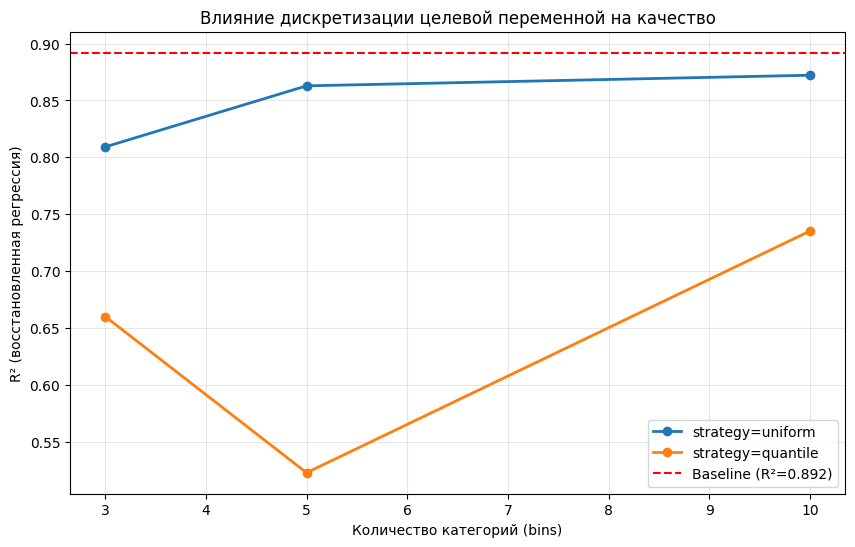

In [20]:
# 5. График
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
for strategy in strategies:
    subset = results_df[results_df['strategy'] == strategy]
    plt.plot(subset['n_bins'], subset['r2'], 'o-', label=f'strategy={strategy}', linewidth=2)
plt.axhline(y=r2_baseline, color='red', linestyle='--', label=f'Baseline (R²={r2_baseline:.3f})')
plt.xlabel('Количество категорий (bins)')
plt.ylabel('R² (восстановленная регрессия)')
plt.title('Влияние дискретизации целевой переменной на качество')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Вывод по заданию 4 (дискретизация целевой переменной)

- **Baseline (непрерывная регрессия):** R² = 0.892 (очень высокое качество)

- **Стратегия `uniform` (равные интервалы):**
  - R² снижается незначительно: от 0.809 (3 bins) до 0.872 (10 bins)
  - При 5–10 категориях качество близко к baseline (≈0.86–0.87)

- **Стратегия `quantile` (равное количество объектов):**
  - Качество значительно хуже: R² = 0.66 (3 bins), 0.52 (5 bins), 0.74 (10 bins)
  - Ниже baseline на 15–37%

- **Общий вывод:**
  - Дискретизация целевой переменной позволяет упростить задачу регрессии до классификации, но за это приходится платить снижением качества.
  - Для данного датасета **лучше использовать `uniform` стратегию с 5–10 категориями** (R² ≈ 0.86–0.87).
  - `quantile` стратегия не подходит, так как сильно искажает распределение целевой переменной.
  - Если исходное качество регрессии уже высокое (0.89), дискретизация имеет смысл только для специфических задач (например, упрощение модели или бинарная классификация).